In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional

In [2]:
SONNETS_FILE = '/content/sonnets.txt'

with open('/content/sonnets.txt') as f:
  data = f.read()

corpus = data.lower().split('\n')

print(f"There are {len(corpus)} lines of sonnets\n")
print(f"The first 5 lines look like this:\n")

for i in range(5):
  print(corpus[i])

There are 2159 lines of sonnets

The first 5 lines look like this:

from fairest creatures we desire increase,
that thereby beauty's rose might never die,
but as the riper should by time decease,
his tender heir might bear his memory:
but thou, contracted to thine own bright eyes,


Tokenizing the text

In [3]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts(corpus)

total_words = len(tokenizer.word_index) + 1

In [4]:
corpus[0]

'from fairest creatures we desire increase,'

In [5]:
tokenizer.texts_to_sequences(corpus[0])

[[],
 [],
 [58],
 [],
 [],
 [],
 [17],
 [6],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [17],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [6],
 [],
 [],
 [],
 [6],
 [],
 [],
 [],
 [],
 [17],
 [],
 [],
 []]

In [6]:
tokenizer.texts_to_sequences([corpus[0]])[0]

[34, 417, 877, 166, 213, 517]

Generating n_grams

In [7]:
def n_gram_seqs(corpus, tokenizer):

  input_sequences = []

  for line in corpus:
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
      ngs = token_list[:i + 1]
      input_sequences.append(ngs)



  return input_sequences

In [8]:
first_example_sequence = n_gram_seqs([corpus[0]], tokenizer)

print("n_gram sequences for first example look like this:\n")
print(first_example_sequence)

n_gram sequences for first example look like this:

[[34, 417], [34, 417, 877], [34, 417, 877, 166], [34, 417, 877, 166, 213], [34, 417, 877, 166, 213, 517]]


In [9]:
next_3_examples_sequence = n_gram_seqs(corpus[1:4], tokenizer)

print("n_gram sequences for next 3 examples look like this:\n")
next_3_examples_sequence

n_gram sequences for next 3 examples look like this:



[[8, 878],
 [8, 878, 134],
 [8, 878, 134, 351],
 [8, 878, 134, 351, 102],
 [8, 878, 134, 351, 102, 156],
 [8, 878, 134, 351, 102, 156, 199],
 [16, 22],
 [16, 22, 2],
 [16, 22, 2, 879],
 [16, 22, 2, 879, 61],
 [16, 22, 2, 879, 61, 30],
 [16, 22, 2, 879, 61, 30, 48],
 [16, 22, 2, 879, 61, 30, 48, 634],
 [25, 311],
 [25, 311, 635],
 [25, 311, 635, 102],
 [25, 311, 635, 102, 200],
 [25, 311, 635, 102, 200, 25],
 [25, 311, 635, 102, 200, 25, 278]]

In [10]:
input_sequences = n_gram_seqs(corpus, tokenizer)

max_sequence_len = max([len(x) for x in input_sequences])

print(f"n_grams of input_sequences have length: {len(input_sequences)}")
print(f"maximum length of sequences is: {max_sequence_len}")

n_grams of input_sequences have length: 15462
maximum length of sequences is: 11


Add padding to the sequences

In [12]:
def pad_seqs(input_sequences, maxlen):

  padded_sequences = pad_sequences(input_sequences, maxlen = maxlen, padding = 'pre')

  return padded_sequences

In [14]:
first_padded_seq = pad_seqs(first_example_sequence, max(len(x) for x in first_example_sequence))

first_padded_seq

array([[  0,   0,   0,   0,  34, 417],
       [  0,   0,   0,  34, 417, 877],
       [  0,   0,  34, 417, 877, 166],
       [  0,  34, 417, 877, 166, 213],
       [ 34, 417, 877, 166, 213, 517]], dtype=int32)

In [15]:
next_3_padded_seq = pad_seqs(next_3_examples_sequence, max(len(x) for x in next_3_examples_sequence))
next_3_padded_seq

array([[  0,   0,   0,   0,   0,   0,   8, 878],
       [  0,   0,   0,   0,   0,   8, 878, 134],
       [  0,   0,   0,   0,   8, 878, 134, 351],
       [  0,   0,   0,   8, 878, 134, 351, 102],
       [  0,   0,   8, 878, 134, 351, 102, 156],
       [  0,   8, 878, 134, 351, 102, 156, 199],
       [  0,   0,   0,   0,   0,   0,  16,  22],
       [  0,   0,   0,   0,   0,  16,  22,   2],
       [  0,   0,   0,   0,  16,  22,   2, 879],
       [  0,   0,   0,  16,  22,   2, 879,  61],
       [  0,   0,  16,  22,   2, 879,  61,  30],
       [  0,  16,  22,   2, 879,  61,  30,  48],
       [ 16,  22,   2, 879,  61,  30,  48, 634],
       [  0,   0,   0,   0,   0,   0,  25, 311],
       [  0,   0,   0,   0,   0,  25, 311, 635],
       [  0,   0,   0,   0,  25, 311, 635, 102],
       [  0,   0,   0,  25, 311, 635, 102, 200],
       [  0,   0,  25, 311, 635, 102, 200,  25],
       [  0,  25, 311, 635, 102, 200,  25, 278]], dtype=int32)

In [16]:
input_sequences = pad_seqs(input_sequences, max_sequence_len)

print(f"padded corpus has shape: {input_sequences.shape}")

padded corpus has shape: (15462, 11)


Split the data into features and labels

In [18]:
def features_and_labels(input_sequences, total_words):

  features = input_sequences[:, :-1]
  labels = input_sequences[:, -1]
  one_hot_labels = to_categorical(labels, num_classes = total_words)

  return features, one_hot_labels

In [19]:
first_features, first_labels = features_and_labels(first_padded_seq, total_words)

print(f"labels have shape: {first_labels.shape}")
print("\nfeatures look like this:\n")
first_features

labels have shape: (5, 3211)

features look like this:



array([[  0,   0,   0,   0,  34],
       [  0,   0,   0,  34, 417],
       [  0,   0,  34, 417, 877],
       [  0,  34, 417, 877, 166],
       [ 34, 417, 877, 166, 213]], dtype=int32)

In [20]:
features, labels = features_and_labels(input_sequences, total_words)

print(f"features have shape: {features.shape}")
print(f"labels have shape: {labels.shape}")

features have shape: (15462, 10)
labels have shape: (15462, 3211)


Create the model

In [21]:
def create_model(total_words, max_sequence_len):

  model = Sequential()

  model.add(Embedding(total_words, 100, input_length = max_sequence_len - 1)),
  model.add(Bidirectional(LSTM(100))),
  model.add(Dense(total_words, activation = 'softmax'))

  model.compile(loss = 'categorical_crossentropy',
                optimizer = 'adam',
                metrics = ['accuracy'])

  return model

In [22]:
model = create_model(total_words, max_sequence_len)

history = model.fit(features, labels, epochs = 50, verbose = 1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.0216 - loss: 6.8924
Epoch 2/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.0330 - loss: 6.4445
Epoch 3/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.0396 - loss: 6.2411
Epoch 4/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.0462 - loss: 6.0270
Epoch 5/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.0589 - loss: 5.7776
Epoch 6/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - accuracy: 0.0671 - loss: 5.5088
Epoch 7/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.0817 - loss: 5.2253
Epoch 8/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.0936 - loss: 4.9502
Epoch 9/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - accuracy: 0.1130 - loss: 4.6755
Epoch 10/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 38s 37ms/step - accuracy: 0.1405 - loss: 4.4071
Epoch 11/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.1758 - loss: 4.1431
Epoch 12/50
484/484 ━━━━━━━━━━

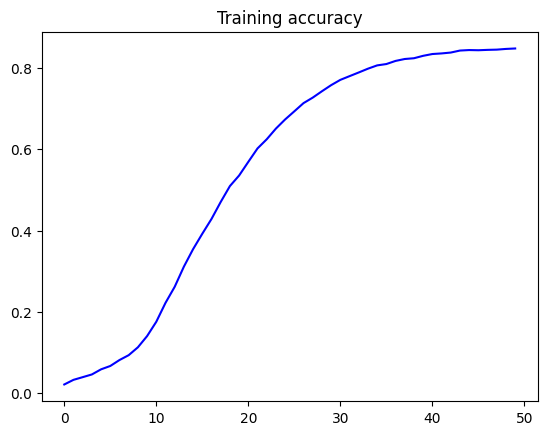

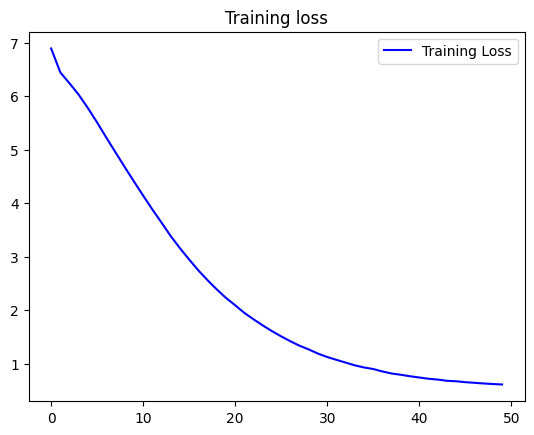

In [23]:
acc = history.history['accuracy']
loss = history.history['loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label = 'Training accuracy')
plt.title('Training accuracy')

plt.figure()

plt.plot(epochs, loss, 'b', label = 'Training Loss')
plt.title('Training loss')
plt.legend()

plt.show()

In [25]:
seed_text = "Help me Obi Wan Kenobi, you're my only hope"
next_words = 100

for _ in range(next_words):

  token_list = tokenizer.texts_to_sequences([seed_text])[0]

  token_list = pad_sequences([token_list], maxlen = max_sequence_len - 1, padding = 'pre')

  predicted = model.predict(token_list, verbose = 0)

  predicted = np.argmax(predicted, axis = -1).item()

  output_word = tokenizer.index_word[predicted]

  seed_text += " " + output_word


print(seed_text)

Help me Obi Wan Kenobi, you're my only hope the world and me knows wide viewest is me loves it so cruel die me none ' me live in me is of more strong contented fair ' grey pale place merchandized welcome wound once more is no more right of fair more worth voice thee painter image ' to itself wide strong heir weakens gain stores once treasure days night ' yourself to have make me smother now housewife tomb confound sweets oppress'd with ink hearts resty ' and they shall see times shall outlive silent ' upon us good faith torn wanting swear me thee more strong survive
